# Pipeline B: PaddleOCR Langsung pada Full Image

Notebook ini menjalankan **Pipeline B** untuk project ALPR Lampung License Plate Detection. Berbeda dengan Pipeline A, notebook ini **tidak memakai YOLOv8** dan **tidak melakukan crop plat**. PaddleOCR dijalankan langsung pada gambar kendaraan penuh, lalu sistem memilih kandidat teks yang paling mirip format plat Lampung.

Tujuan Pipeline B adalah menjadi baseline pembanding yang adil: apakah OCR full image cukup baik, atau apakah tahap deteksi plat dengan YOLO pada Pipeline A memang membantu mengurangi noise dan meningkatkan akurasi.

## 1. Diagram Alur Pipeline B

```mermaid
flowchart TD
    A["Gambar kendaraan penuh"] --> B["PaddleOCR membaca semua teks"]
    B --> C["Ambil kandidat teks mirip plat BE"]
    C --> D["Ekstrak kode wilayah"]
    D --> E["Bandingkan dengan ground truth"]
    E --> F["Evaluasi Pipeline B"]
```

Pipeline B lebih sederhana secara struktur karena tidak ada YOLO. Namun, karena OCR membaca seluruh gambar, ia lebih rentan membaca teks lain seperti merek kendaraan, stiker, tanggal masa berlaku, background, atau objek kecil yang bukan nomor plat utama.

## 2. Prinsip Evaluasi

Aturan penting notebook ini:

- Tidak menggunakan YOLO.
- Tidak memakai crop hasil YOLO.
- Tidak memakai bounding box ground truth.
- Tidak memakai `plat_gt` untuk memilih prediksi.
- Ground truth hanya digunakan untuk menghitung metrik dan analisis error.
- Candidate extraction memakai domain knowledge umum plat Lampung: `BE + 1 sampai 4 digit + 1 sampai 3 huruf`.
- Kandidat dipilih dari OCR line satu per satu. Gabungan semua line hanya dipakai sebagai fallback.

## 3. Penjelasan Metrik

- **OCR berhasil membaca**: PaddleOCR berjalan dan menghasilkan teks.
- **Plat berhasil diparsing**: dari hasil OCR ditemukan kandidat yang cocok dengan pola plat BE.
- **Akurasi teks plat persis**: hasil prediksi sama persis dengan ground truth.
- **CER / Kesalahan Karakter**: rata-rata proporsi karakter yang salah. Nilai lebih kecil lebih baik.
- **Akurasi karakter**: kebalikan dari CER. Nilai lebih tinggi lebih baik.
- **Akurasi wilayah**: apakah huruf belakang plat berhasil dipetakan ke kabupaten/kota yang benar.

## 4. Mount Google Drive

Semua input dataset dan output eksperimen disimpan di Google Drive. Pastikan folder dataset final sudah berada di `MyDrive`.

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


## 5. Install Dependency dan Paddle Environment Flags

PaddleOCR pernah bermasalah pada runtime Colab tertentu jika mengambil versi terbaru otomatis. Karena itu versi PaddlePaddle dan PaddleOCR dipin seperti Pipeline A, serta flag MKLDNN/oneDNN/PIR dimatikan sebelum import Paddle.

Jika runtime sebelumnya sudah pernah import `paddle` atau `paddleocr`, lakukan `Runtime > Disconnect and delete runtime`, lalu jalankan notebook dari awal.

In [2]:
import os
os.environ["FLAGS_use_mkldnn"] = "0"
os.environ["FLAGS_use_onednn"] = "0"
os.environ["FLAGS_enable_pir_api"] = "0"
os.environ["PADDLE_PDX_DISABLE_MODEL_SOURCE_CHECK"] = "True"

import subprocess
import sys

subprocess.run([sys.executable, "-m", "pip", "uninstall", "-y", "paddlepaddle", "paddleocr", "paddlex"], check=False)
subprocess.check_call([
    sys.executable, "-m", "pip", "install", "-q",
    "paddlepaddle==3.2.2",
    "paddleocr==3.4.1",
    "opencv-python",
    "pandas",
    "matplotlib",
    "pyyaml",
    "rapidfuzz",
    "tqdm",
    "langchain-text-splitters",
    "langchain-community",
])

print("Dependency berhasil diinstall.")

Dependency berhasil diinstall.


## 6. Cek Environment

Cell ini menampilkan versi Python, PaddlePaddle, PaddleOCR, dan status CUDA Paddle. Pipeline B tidak memakai YOLO, sehingga tidak perlu memuat model deteksi.

In [3]:
import sys
import platform
import paddle
import paddleocr

print("Python version:", sys.version)
print("Platform:", platform.platform())
print("paddle version:", paddle.__version__)
print("paddleocr version:", getattr(paddleocr, "__version__", "unknown"))
print("CUDA available in paddle:", paddle.is_compiled_with_cuda())

/usr/local/lib/python3.12/dist-packages/paddle/utils/cpp_extension/extension_utils.py:718: UserWarning: No ccache found. Please be aware that recompiling all source files may be required. You can download and install ccache from: https://github.com/ccache/ccache/blob/master/doc/INSTALL.md
  warnings.warn(warning_message)
Connectivity check to the model hoster has been skipped because `PADDLE_PDX_DISABLE_MODEL_SOURCE_CHECK` is enabled.


Python version: 3.12.13 (main, Mar  4 2026, 09:23:07) [GCC 11.4.0]
Platform: Linux-6.6.122+-x86_64-with-glibc2.35
paddle version: 3.2.2
paddleocr version: 3.4.1
CUDA available in paddle: False


## 7. Import Library

Notebook memakai OpenCV untuk membaca gambar, PaddleOCR untuk OCR, pandas untuk evaluasi, matplotlib untuk visualisasi, dan rapidfuzz untuk menghitung CER.

In [4]:
from pathlib import Path
import json
import math
import os
import random
import re
import shutil
import time
from typing import Any, Dict, List, Optional, Tuple

import cv2
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from rapidfuzz.distance import Levenshtein
from tqdm.auto import tqdm
from paddleocr import PaddleOCR

## 8. Konfigurasi Path dan Output

Pipeline B memakai split yang sama dengan Pipeline A. Default evaluasi adalah `test`. Semua file hasil ramah pembaca disimpan langsung di folder `pipeline_b`, sedangkan detail teknis disimpan di subfolder `technical_outputs`.

In [5]:
DATASET_ROOT = "/content/drive/MyDrive/ALPR-Lampung-final"
GT_PATH = f"{DATASET_ROOT}/ground_truth_with_split.csv"
OUTPUT_ROOT = "/content/drive/MyDrive/ALPR-Lampung-results/pipeline_b"

EVAL_SPLIT = "test"
IMAGE_DIR = f"{DATASET_ROOT}/{EVAL_SPLIT}/images"
RANDOM_SEED = 42

RUN_OCR_SMOKE_TEST = True
DEBUG_NUM_IMAGES = 3
SAVE_VISUALIZATIONS = True

DATASET_ROOT_PATH = Path(DATASET_ROOT)
GT_PATH_OBJ = Path(GT_PATH)
OUTPUT_ROOT_PATH = Path(OUTPUT_ROOT)
IMAGE_DIR_PATH = Path(IMAGE_DIR)

TECHNICAL_DIR = OUTPUT_ROOT_PATH / "technical_outputs"
VIS_DIR = OUTPUT_ROOT_PATH / "visualisasi_hasil"
OCR_TEMP_DIR = TECHNICAL_DIR / "ocr_temp_full_image"

for d in [OUTPUT_ROOT_PATH, TECHNICAL_DIR, VIS_DIR, OCR_TEMP_DIR]:
    d.mkdir(parents=True, exist_ok=True)

random.seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)

print("Dataset root:", DATASET_ROOT_PATH)
print("GT path:", GT_PATH_OBJ)
print("Eval split:", EVAL_SPLIT)
print("Image dir:", IMAGE_DIR_PATH)
print("Output root:", OUTPUT_ROOT_PATH)

Dataset root: /content/drive/MyDrive/ALPR-Lampung-final
GT path: /content/drive/MyDrive/ALPR-Lampung-final/ground_truth_with_split.csv
Eval split: test
Image dir: /content/drive/MyDrive/ALPR-Lampung-final/test/images
Output root: /content/drive/MyDrive/ALPR-Lampung-results/pipeline_b


## 9. Load dan Validasi Ground Truth

Ground truth dipakai hanya untuk evaluasi. Prediksi Pipeline B tidak boleh menggunakan `plat_gt` untuk memilih kandidat.

In [6]:
required_paths = {
    "GT_PATH": GT_PATH_OBJ,
    "IMAGE_DIR": IMAGE_DIR_PATH,
}
missing_paths = [f"{name}: {path}" for name, path in required_paths.items() if not path.exists()]
if missing_paths:
    raise FileNotFoundError("Path penting tidak ditemukan:\n" + "\n".join(missing_paths))

gt_df = pd.read_csv(GT_PATH_OBJ)
required_cols = ["filename", "plat_gt", "kode_wilayah_gt", "wilayah_gt", "split"]
missing_cols = [c for c in required_cols if c not in gt_df.columns]
if missing_cols:
    raise ValueError(f"Kolom ground truth tidak lengkap: {missing_cols}")

for col in required_cols:
    gt_df[col] = gt_df[col].astype(str).str.strip()

if gt_df["filename"].duplicated().any():
    display(gt_df[gt_df["filename"].duplicated(keep=False)].sort_values("filename"))
    raise ValueError("Ada filename duplikat pada ground_truth_with_split.csv")

eval_gt_df = gt_df[gt_df["split"] == EVAL_SPLIT].copy().reset_index(drop=True)
if len(eval_gt_df) == 0:
    raise ValueError(f"Tidak ada data untuk split {EVAL_SPLIT}")

image_files = {p.name: p for p in IMAGE_DIR_PATH.iterdir() if p.is_file() and p.suffix.lower() in {".jpg", ".jpeg", ".png"}}
missing_images = sorted(set(eval_gt_df["filename"]) - set(image_files))
if missing_images:
    display(pd.DataFrame({"missing_filename": missing_images}))
    raise FileNotFoundError("Beberapa filename ground truth tidak ditemukan di folder image.")

print("Jumlah gambar pada split evaluasi:", len(eval_gt_df))
display(eval_gt_df.head())

Jumlah gambar pada split evaluasi: 12


,filename,split,plat_gt,kode_wilayah_gt,wilayah_gt,roboflow_image_filename,roboflow_label_filename,base_id_mapping,clean_image_filename,clean_label_filename,matched_ground_truth,status,notes,filename_original,base_id,plat_gt_key,stratify_key
0,alpr_lampung_000001.jpg,test,BE 1943 FL,F,Kota Metro,alpr_lampung_000001_jpg.rf.uj1dwJiAHNTmuRgVh3m...,alpr_lampung_000001_jpg.rf.uj1dwJiAHNTmuRgVh3m...,alpr_lampung_000001,alpr_lampung_000001.jpg,alpr_lampung_000001.txt,True,matched,OK,alpr_lampung_000001.jpg,alpr_lampung_000001,BE 1943 FL,F
1,alpr_lampung_000015.jpg,test,BE 1282 ANG,A,Kota Bandar Lampung,alpr_lampung_000015_jpg.rf.btGYYaaJmev50cRYFWr...,alpr_lampung_000015_jpg.rf.btGYYaaJmev50cRYFWr...,alpr_lampung_000015,alpr_lampung_000015.jpg,alpr_lampung_000015.txt,True,matched,OK,alpr_lampung_000015.jpg,alpr_lampung_000015,BE 1282 ANG,A
2,alpr_lampung_000026.jpg,test,BE 1193 ALQ,A,Kota Bandar Lampung,alpr_lampung_000026_jpg.rf.gG7VQCTxT4GDDXHGTMH...,alpr_lampung_000026_jpg.rf.gG7VQCTxT4GDDXHGTMH...,alpr_lampung_000026,alpr_lampung_000026.jpg,alpr_lampung_000026.txt,True,matched,OK,alpr_lampung_000026.jpg,alpr_lampung_000026,BE 1193 ALQ,A
3,alpr_lampung_000036.jpg,test,BE 1498 GP,G,Kabupaten Lampung Tengah,alpr_lampung_000036_jpg.rf.foEO9kXZRpeUMCpr5jq...,alpr_lampung_000036_jpg.rf.foEO9kXZRpeUMCpr5jq...,alpr_lampung_000036,alpr_lampung_000036.jpg,alpr_lampung_000036.txt,True,matched,OK,alpr_lampung_000036.jpg,alpr_lampung_000036,BE 1498 GP,G
4,alpr_lampung_000044.jpg,test,BE 2581 GDC,G,Kabupaten Lampung Tengah,alpr_lampung_000044_jpg.rf.gYpI3aN9yX6lghO7rE2...,alpr_lampung_000044_jpg.rf.gYpI3aN9yX6lghO7rE2...,alpr_lampung_000044,alpr_lampung_000044.jpg,alpr_lampung_000044.txt,True,matched,OK,alpr_lampung_000044.jpg,alpr_lampung_000044,BE 2581 GDC,G


## 10. Load PaddleOCR

PaddleOCR dijalankan langsung pada full image. Tidak ada model YOLO pada notebook ini.

In [7]:
ocr = PaddleOCR(
    lang="en",
    use_doc_orientation_classify=False,
    use_doc_unwarping=False,
    use_textline_orientation=False,
    text_detection_model_name="PP-OCRv5_mobile_det",
    text_recognition_model_name="PP-OCRv5_mobile_rec",
)
print("PaddleOCR loaded.")

/tmp/ipykernel_1556/2594226173.py:1: UserWarning: `lang` and `ocr_version` will be ignored when model names or model directories are not `None`.
  ocr = PaddleOCR(
Creating model: ('PP-OCRv5_mobile_det', None)
Using official model (PP-OCRv5_mobile_det), the model files will be automatically downloaded and saved in `/root/.paddlex/official_models/PP-OCRv5_mobile_det`.
/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


Fetching 6 files:   0%|          | 0/6 [00:00<?, ?it/s]

Creating model: ('PP-OCRv5_mobile_rec', None)
Using official model (PP-OCRv5_mobile_rec), the model files will be automatically downloaded and saved in `/root/.paddlex/official_models/PP-OCRv5_mobile_rec`.


Fetching 6 files:   0%|          | 0/6 [00:00<?, ?it/s]

PaddleOCR loaded.


## 11. Fungsi Normalisasi, Mapping Wilayah, dan Metrik

Fungsi ini konsisten dengan Pipeline A. Suffix belakang plat tetap mendukung 1 sampai 3 huruf. Ground truth hanya dipakai saat menghitung metrik.

In [8]:
REGION_MAP = {
    'A': 'Kota Bandar Lampung', 'B': 'Kota Bandar Lampung', 'C': 'Kota Bandar Lampung', 'Y': 'Kota Bandar Lampung',
    'F': 'Kota Metro',
    'D': 'Kab. Lampung Selatan', 'E': 'Kab. Lampung Selatan', 'O': 'Kab. Lampung Selatan',
    'M': 'Kab. Lampung Barat',
    'G': 'Kab. Lampung Tengah', 'H': 'Kab. Lampung Tengah', 'I': 'Kab. Lampung Tengah',
    'R': 'Kab. Pesawaran',
    'U': 'Kab. Pringsewu',
    'X': 'Kab. Pesisir Barat',
    'N': 'Kab. Lampung Timur', 'P': 'Kab. Lampung Timur',
    'J': 'Kab. Lampung Utara', 'K': 'Kab. Lampung Utara',
    'V': 'Kab. Tanggamus', 'Z': 'Kab. Tanggamus',
    'W': 'Kab. Way Kanan',
    'S': 'Kab. Tulang Bawang', 'T': 'Kab. Tulang Bawang',
    'Q': 'Kab. Tulang Bawang Barat',
    'L': 'Kab. Mesuji',
}

REGION_NAME_ALIASES = {
    'KABUPATEN LAMPUNG SELATAN': 'KAB. LAMPUNG SELATAN',
    'KABUPATEN LAMPUNG BARAT': 'KAB. LAMPUNG BARAT',
    'KABUPATEN LAMPUNG TENGAH': 'KAB. LAMPUNG TENGAH',
    'KABUPATEN PESAWARAN': 'KAB. PESAWARAN',
    'KABUPATEN PRINGSEWU': 'KAB. PRINGSEWU',
    'KABUPATEN PESISIR BARAT': 'KAB. PESISIR BARAT',
    'KABUPATEN LAMPUNG TIMUR': 'KAB. LAMPUNG TIMUR',
    'KABUPATEN LAMPUNG UTARA': 'KAB. LAMPUNG UTARA',
    'KABUPATEN TANGGAMUS': 'KAB. TANGGAMUS',
    'KABUPATEN WAY KANAN': 'KAB. WAY KANAN',
    'KABUPATEN TULANG BAWANG': 'KAB. TULANG BAWANG',
    'KABUPATEN TULANG BAWANG BARAT': 'KAB. TULANG BAWANG BARAT',
    'KABUPATEN MESUJI': 'KAB. MESUJI',
}


def normalize_plate_text(text: Any) -> str:
    if text is None or (isinstance(text, float) and pd.isna(text)):
        return ''
    normalized = str(text).upper()
    normalized = re.sub(r'[^A-Z0-9]', '', normalized)
    if normalized.startswith(('8E', '6E')):
        normalized = 'BE' + normalized[2:]
    elif normalized.startswith('B3'):
        normalized = 'BE' + normalized[2:]
    elif normalized.startswith('13E'):
        normalized = 'BE' + normalized[3:]
    return normalized


def format_plate_text(text: Any) -> str:
    normalized = normalize_plate_text(text)
    match = re.match(r'^(BE)(\d{1,4})([A-Z]{1,3})$', normalized)
    if match:
        return f"{match.group(1)} {match.group(2)} {match.group(3)}"
    return normalized


def extract_region_code(plate_text: Any) -> str:
    normalized = normalize_plate_text(plate_text)
    match = re.match(r'^BE\d{1,4}([A-Z]{1,3})$', normalized)
    if not match:
        return ''
    return match.group(1)[0]


def identify_region_from_code(code: Any) -> str:
    if code is None:
        return 'unknown'
    code = str(code).upper().strip()[:1]
    return REGION_MAP.get(code, 'unknown')


def normalize_region_name(name: Any) -> str:
    if name is None or pd.isna(name):
        return ''
    text = str(name).upper().strip()
    text = re.sub(r'\s+', ' ', text)
    return REGION_NAME_ALIASES.get(text, text)


def compute_cer(gt: Any, pred: Any) -> float:
    gt_norm = normalize_plate_text(gt)
    pred_norm = normalize_plate_text(pred)
    if len(gt_norm) == 0:
        return 0.0 if len(pred_norm) == 0 else 1.0
    return Levenshtein.distance(gt_norm, pred_norm) / len(gt_norm)


def compute_character_accuracy(gt: Any, pred: Any) -> float:
    return max(0.0, min(1.0, 1.0 - compute_cer(gt, pred)))

## 12. Parser Output PaddleOCR

PaddleOCR v3 mengembalikan output yang bisa berupa list, dict, atau object result. Parser ini mengambil `rec_texts`, `rec_scores`, dan box OCR jika tersedia.

In [9]:
def _box_to_xy_stats(box: Any, shape: Tuple[int, int]) -> Dict[str, Optional[float]]:
    h, w = shape[:2]
    try:
        arr = np.asarray(box, dtype=float)
        if arr.size == 0:
            return {}
        if arr.ndim == 1 and arr.size >= 4:
            xs = [arr[0], arr[2]]
            ys = [arr[1], arr[3]]
        elif arr.ndim >= 2 and arr.shape[-1] >= 2:
            xs = arr[..., 0].reshape(-1)
            ys = arr[..., 1].reshape(-1)
        else:
            return {}
        x_min, x_max = float(np.min(xs)), float(np.max(xs))
        y_min, y_max = float(np.min(ys)), float(np.max(ys))
        return {
            'x_min': x_min, 'x_max': x_max, 'y_min': y_min, 'y_max': y_max,
            'center_y_ratio': ((y_min + y_max) / 2) / max(1, h),
            'center_x_ratio': ((x_min + x_max) / 2) / max(1, w),
            'height_ratio': (y_max - y_min) / max(1, h),
            'width_ratio': (x_max - x_min) / max(1, w),
        }
    except Exception:
        return {}


def _safe_repr(obj: Any, max_len: int = 2000) -> str:
    try:
        text = repr(obj)
    except Exception as exc:
        text = f'<repr_failed: {exc}>'
    text = text.replace('\n', ' ')
    return text[:max_len]


def _safe_type_name(obj: Any) -> str:
    try:
        return f'{type(obj).__module__}.{type(obj).__name__}'
    except Exception:
        return str(type(obj))


def _maybe_get_attr_payload(obj: Any, attr_name: str) -> Any:
    if not hasattr(obj, attr_name):
        return None
    try:
        attr = getattr(obj, attr_name)
        return attr() if callable(attr) else attr
    except Exception:
        return None


def _dict_first_present(obj: Dict[str, Any], keys: List[str]) -> Any:
    for key in keys:
        if key in obj and obj[key] is not None:
            return obj[key]
    return None


def _as_list(value: Any) -> List[Any]:
    if value is None:
        return []
    if isinstance(value, np.ndarray):
        if value.ndim == 0:
            return [value.item()]
        return [item for item in value]
    if isinstance(value, (list, tuple)):
        return list(value)
    return [value]


def _append_lines_from_dict(obj: Dict[str, Any], lines: List[Dict[str, Any]], image_shape: Optional[Tuple[int, int]]) -> None:
    texts = _as_list(_dict_first_present(obj, ['rec_texts', 'texts', 'text']))
    scores = _as_list(_dict_first_present(obj, ['rec_scores', 'scores', 'score', 'confidence']))
    boxes = _as_list(_dict_first_present(obj, ['rec_boxes', 'rec_polys', 'dt_polys', 'boxes', 'polys']))

    if not texts:
        return

    for idx, text in enumerate(texts):
        text = str(text).strip()
        if not text:
            continue
        score = None
        if idx < len(scores):
            try:
                score = float(scores[idx])
            except Exception:
                score = None
        box = boxes[idx] if idx < len(boxes) else None
        stats = _box_to_xy_stats(box, image_shape) if (box is not None and image_shape is not None) else {}
        lines.append({'text': text, 'score': score, 'box': box, **stats})


def parse_paddleocr_output(output: Any, image_shape: Optional[Tuple[int, int]] = None) -> Tuple[str, Optional[float], List[Dict[str, Any]], str, str]:
    lines: List[Dict[str, Any]] = []
    visited = set()

    def collect(obj: Any) -> None:
        if obj is None:
            return
        obj_id = id(obj)
        if obj_id in visited:
            return
        visited.add(obj_id)

        if isinstance(obj, dict):
            _append_lines_from_dict(obj, lines, image_shape)
            for key in ['res', 'result', 'data', 'ocr_res', 'page_res']:
                if key in obj:
                    collect(obj[key])
            for value in obj.values():
                if isinstance(value, (dict, list, tuple)) or hasattr(value, 'json') or hasattr(value, 'res') or hasattr(value, 'to_dict'):
                    collect(value)
            return

        for attr_name in ['json', 'res', 'to_dict', 'as_dict']:
            payload = _maybe_get_attr_payload(obj, attr_name)
            if payload is not None:
                collect(payload)

        if isinstance(obj, (list, tuple)):
            if len(obj) >= 2 and isinstance(obj[1], (tuple, list)) and len(obj[1]) >= 2:
                maybe_text = obj[1][0]
                if isinstance(maybe_text, str) and maybe_text.strip():
                    try:
                        score = float(obj[1][1])
                    except Exception:
                        score = None
                    stats = _box_to_xy_stats(obj[0], image_shape) if image_shape is not None else {}
                    lines.append({'text': maybe_text.strip(), 'score': score, 'box': obj[0], **stats})
                    return
            for item in obj:
                collect(item)

    try:
        collect(output)
    except Exception as exc:
        return '', None, [], 'parser_error', str(exc)

    dedup = []
    seen = set()
    for line in lines:
        key = (line.get('text'), round(float(line.get('score') or 0), 4), _safe_repr(line.get('box'), 120))
        if key not in seen:
            seen.add(key)
            dedup.append(line)
    lines = dedup

    text = ' '.join([str(line.get('text', '')).strip() for line in lines if str(line.get('text', '')).strip()])
    scores = [line['score'] for line in lines if line.get('score') is not None]
    conf = float(np.mean(scores)) if scores else None

    raw_repr = _safe_repr(output, 500)
    if text:
        return text, conf, lines, 'ok', ''
    if output is not None and raw_repr not in ['[]', '{}', 'None']:
        return '', conf, lines, 'empty', 'raw output exists but parser extracted no text'
    return '', conf, lines, 'empty', ''


def serialize_ocr_lines(lines: List[Dict[str, Any]]) -> str:
    compact = []
    for line in lines or []:
        compact.append({
            'text': line.get('text'),
            'score': None if line.get('score') is None else float(line.get('score')),
            'center_x_ratio': None if line.get('center_x_ratio') is None else float(line.get('center_x_ratio')),
            'center_y_ratio': None if line.get('center_y_ratio') is None else float(line.get('center_y_ratio')),
            'height_ratio': None if line.get('height_ratio') is None else float(line.get('height_ratio')),
            'width_ratio': None if line.get('width_ratio') is None else float(line.get('width_ratio')),
        })
    return json.dumps(compact, ensure_ascii=False)

## 13. OCR Runner Robust untuk Full Image

Runner ini mencoba beberapa mode input PaddleOCR. Biasanya `predict_path` paling stabil. Fallback tetap tersedia untuk diagnosis, tetapi prediksi utama tidak bergantung pada API lama.

In [10]:
OCR_MODES = ['predict_path', 'predict_bgr', 'predict_rgb', 'legacy_ocr_path', 'legacy_ocr_bgr']
ocr_debug_rows: List[Dict[str, Any]] = []


def _prepare_ocr_image(image: Optional[np.ndarray]) -> Optional[np.ndarray]:
    if image is None:
        return None
    arr = np.asarray(image)
    if arr.ndim == 2:
        arr = cv2.cvtColor(arr, cv2.COLOR_GRAY2BGR)
    if arr.ndim == 3 and arr.shape[2] == 4:
        arr = cv2.cvtColor(arr, cv2.COLOR_BGRA2BGR)
    if arr.dtype != np.uint8:
        arr = np.clip(arr, 0, 255).astype(np.uint8)
    return np.ascontiguousarray(arr)


def _debug_shape(image: Optional[np.ndarray]) -> str:
    return '' if image is None else str(tuple(image.shape))


def _debug_dtype(image: Optional[np.ndarray]) -> str:
    return '' if image is None else str(image.dtype)


def _make_temp_image_path(source_name: str, image_name: str, temp_dir: Path) -> Path:
    safe_stem = re.sub(r'[^A-Za-z0-9_\-]+', '_', Path(str(image_name)).stem or 'image')
    safe_source = re.sub(r'[^A-Za-z0-9_\-]+', '_', source_name or 'source')
    return temp_dir / f'{safe_stem}_{safe_source}_ocr_input.jpg'


def _run_single_ocr_mode(image_bgr: np.ndarray, mode: str, temp_path: Path) -> Dict[str, Any]:
    output = None
    try:
        if mode == 'predict_path':
            if not hasattr(ocr, 'predict'):
                raise AttributeError('PaddleOCR object has no predict() method')
            output = ocr.predict(str(temp_path))
        elif mode == 'predict_bgr':
            if not hasattr(ocr, 'predict'):
                raise AttributeError('PaddleOCR object has no predict() method')
            output = ocr.predict(image_bgr)
        elif mode == 'predict_rgb':
            if not hasattr(ocr, 'predict'):
                raise AttributeError('PaddleOCR object has no predict() method')
            image_rgb = cv2.cvtColor(image_bgr, cv2.COLOR_BGR2RGB)
            output = ocr.predict(image_rgb)
        elif mode == 'legacy_ocr_path':
            if not hasattr(ocr, 'ocr'):
                raise AttributeError('PaddleOCR object has no ocr() method')
            output = ocr.ocr(str(temp_path))
        elif mode == 'legacy_ocr_bgr':
            if not hasattr(ocr, 'ocr'):
                raise AttributeError('PaddleOCR object has no ocr() method')
            output = ocr.ocr(image_bgr)
        else:
            raise ValueError(f'Unknown OCR mode: {mode}')

        parsed_text, parsed_conf, lines, parse_status, parse_warning = parse_paddleocr_output(output, image_bgr.shape)
        status = 'ok' if parsed_text.strip() else 'ocr_empty'
        return {
            'mode': mode,
            'status': status,
            'ocr_execution_status': 'ok',
            'ocr_parse_status': parse_status,
            'error_message': '',
            'parse_warning': parse_warning,
            'raw_output_type': _safe_type_name(output),
            'raw_output_repr_sample': _safe_repr(output, 2000),
            'parsed_text': parsed_text,
            'parsed_confidence': parsed_conf,
            'lines': lines,
        }
    except Exception as exc:
        return {
            'mode': mode,
            'status': 'ocr_error',
            'ocr_execution_status': 'error',
            'ocr_parse_status': 'not_run',
            'error_message': str(exc),
            'parse_warning': '',
            'raw_output_type': _safe_type_name(output) if output is not None else '',
            'raw_output_repr_sample': _safe_repr(output, 2000) if output is not None else '',
            'parsed_text': '',
            'parsed_confidence': None,
            'lines': [],
        }


def run_paddleocr_robust(
    image: Optional[np.ndarray],
    source_name: str,
    temp_dir: Path,
    image_name: str = '',
    collect_debug: bool = True,
) -> Dict[str, Any]:
    image_bgr = _prepare_ocr_image(image)
    base = {
        'source': source_name,
        'raw_text': '',
        'confidence': None,
        'status': 'no_image' if image_bgr is None else 'not_started',
        'error': '',
        'ocr_execution_status': 'not_run',
        'ocr_parse_status': 'not_run',
        'parse_warning': '',
        'mode_used': '',
        'raw_output_type': '',
        'raw_output_repr_sample': '',
        'input_shape': _debug_shape(image_bgr),
        'input_dtype': _debug_dtype(image_bgr),
        'lines': [],
    }
    if image_bgr is None:
        return base

    temp_dir.mkdir(parents=True, exist_ok=True)
    temp_path = _make_temp_image_path(source_name, image_name, temp_dir)
    try:
        ok_write = cv2.imwrite(str(temp_path), image_bgr)
        if not ok_write:
            raise ValueError(f'cv2.imwrite gagal untuk temporary OCR image: {temp_path}')
    except Exception as exc:
        base.update({'status': 'ocr_error', 'ocr_execution_status': 'error', 'error': f'temp_file_error: {exc}'})
        return base

    attempts = []
    best_empty = None
    successful = None
    for mode in OCR_MODES:
        attempt = _run_single_ocr_mode(image_bgr, mode, temp_path)
        attempt.update({
            'image_name': image_name,
            'source_name': source_name,
            'input_shape': base['input_shape'],
            'input_dtype': base['input_dtype'],
            'temp_path': str(temp_path),
        })
        attempts.append(attempt)
        if collect_debug:
            ocr_debug_rows.append({
                'image_name': image_name,
                'source_name': source_name,
                'mode': mode,
                'status': attempt['status'],
                'ocr_execution_status': attempt['ocr_execution_status'],
                'ocr_parse_status': attempt['ocr_parse_status'],
                'error_message': attempt['error_message'],
                'parse_warning': attempt['parse_warning'],
                'raw_output_type': attempt['raw_output_type'],
                'raw_output_repr_sample': attempt['raw_output_repr_sample'],
                'parsed_text': attempt['parsed_text'],
                'parsed_confidence': attempt['parsed_confidence'],
                'input_shape': base['input_shape'],
                'input_dtype': base['input_dtype'],
                'temp_path': str(temp_path),
            })
        if attempt['status'] == 'ok':
            successful = attempt
            break
        if attempt['ocr_execution_status'] == 'ok' and best_empty is None:
            best_empty = attempt

    chosen = successful or best_empty
    if chosen is None:
        error_messages = [f"{a['mode']}: {a['error_message']}" for a in attempts if a.get('error_message')]
        base.update({
            'status': 'ocr_error',
            'ocr_execution_status': 'error',
            'ocr_parse_status': 'not_run',
            'error': ' | '.join(error_messages)[:4000],
            'mode_used': attempts[-1]['mode'] if attempts else '',
        })
        return base

    base.update({
        'raw_text': chosen['parsed_text'],
        'confidence': chosen['parsed_confidence'],
        'status': chosen['status'],
        'error': chosen['error_message'],
        'ocr_execution_status': chosen['ocr_execution_status'],
        'ocr_parse_status': chosen['ocr_parse_status'],
        'parse_warning': chosen['parse_warning'],
        'mode_used': chosen['mode'],
        'raw_output_type': chosen['raw_output_type'],
        'raw_output_repr_sample': chosen['raw_output_repr_sample'],
        'lines': chosen.get('lines', []),
    })
    return base

## 14. Candidate Extraction Khusus Pipeline B

Pipeline B membaca full image, sehingga OCR bisa menangkap banyak teks non-plat. Scoring kandidat memperhatikan pola plat, confidence OCR, geometri text box, dan penalti noise. Kandidat dari OCR line lebih diprioritaskan daripada gabungan semua line.

In [11]:
NON_PLATE_WORDS = {
    'HONDA', 'YAMAHA', 'TOYOTA', 'DAIHATSU', 'SUZUKI', 'MITSUBISHI', 'NISSAN',
    'ONEHEART', 'ONE', 'HEART', 'VARIO', 'BEAT', 'AVANZA', 'INNOVA', 'BRIO',
    'CIVIC', 'JAZZ', 'MOBIL', 'MOTOR'
}
COMMON_TWO_LETTER_SUFFIXES = {'FL', 'FT', 'FR', 'GP', 'BW', 'RG', 'CF', 'HX', 'KK'}


def _contextual_clean_for_plate(text: Any) -> str:
    clean = normalize_plate_text(text)
    if clean.startswith(('8E', '6E')):
        clean = 'BE' + clean[2:]
    return clean


def _geometry_score(line: Optional[Dict[str, Any]]) -> float:
    if not line:
        return -4.0
    w = line.get('width_ratio')
    h = line.get('height_ratio')
    cy = line.get('center_y_ratio')
    score = 0.0
    if w is not None and h is not None and h > 0:
        aspect = w / max(h, 1e-6)
        if aspect >= 2.0:
            score += 6.0
        elif aspect < 1.0:
            score -= 5.0
        if 0.035 <= w <= 0.95:
            score += 4.0
        elif w < 0.02:
            score -= 8.0
        if 0.008 <= h <= 0.18:
            score += 4.0
        elif h < 0.006:
            score -= 8.0
    if cy is not None:
        if 0.05 <= cy <= 0.95:
            score += 2.0
        else:
            score -= 4.0
    return score


def _noise_penalty(raw_text: str, trailing_noise: str, source_kind: str) -> Tuple[float, List[str]]:
    notes = []
    penalty = 0.0
    raw_clean = normalize_plate_text(raw_text)
    words = re.findall(r'[A-Z]+', str(raw_text).upper())
    non_plate_hits = [w for w in words if w in NON_PLATE_WORDS]
    if non_plate_hits:
        penalty -= 8.0 * len(non_plate_hits)
        notes.append(f"non-plate word detected: {','.join(non_plate_hits)}")
    if trailing_noise:
        notes.append(f"removed trailing noise: {trailing_noise}")
        if re.search(r'\d{2,4}', trailing_noise):
            penalty -= 1.0
            notes.append("date-like trailing noise removed")
        else:
            penalty -= min(len(trailing_noise), 12) * 0.7
    if len(raw_clean) > 14 and source_kind.endswith('_joined'):
        penalty -= 8.0
        notes.append("joined text too long")
    if re.fullmatch(r'\d{2,4}', raw_clean):
        penalty -= 30.0
        notes.append("numeric-only line likely date")
    return penalty, notes


def _generate_plate_candidates_from_text_item(item: Dict[str, Any]) -> List[Dict[str, Any]]:
    source = item.get('source', 'full_image')
    source_kind = item.get('source_kind', 'full_image_line')
    raw_line = str(item.get('raw_line', item.get('text', '')))
    source_text_all = str(item.get('source_text_all', raw_line))
    confidence = item.get('confidence')
    line_index = item.get('line_index')
    line = item.get('line')
    clean = _contextual_clean_for_plate(item.get('text', ''))
    candidates = []

    for match in re.finditer(r'BE([0-9]{1,4})([A-Z0-9]{1,12})', clean):
        digits = match.group(1)
        tail = match.group(2)
        letter_match = re.match(r'([A-Z]{1,6})(.*)', tail)
        if not letter_match:
            continue
        letter_run = letter_match.group(1)
        after_letter_run = letter_match.group(2)
        max_suffix_len = min(3, len(letter_run))
        for suffix_len in range(1, max_suffix_len + 1):
            suffix = letter_run[:suffix_len]
            trailing_noise = letter_run[suffix_len:] + after_letter_run + clean[match.end():]
            candidate_norm = f'BE{digits}{suffix}'
            if not re.match(r'^BE\d{1,4}[A-Z]{1,3}$', candidate_norm):
                continue

            pattern_score = 100.0 + suffix_len * 2.0
            if suffix_len == 3:
                pattern_score += 4.0
            if not trailing_noise:
                pattern_score += 8.0
            elif re.search(r'\d{2,4}', trailing_noise):
                pattern_score += 2.0

            if suffix_len == 3 and suffix[:2] in COMMON_TWO_LETTER_SUFFIXES and trailing_noise:
                pattern_score -= 18.0
            if suffix_len < 3 and len(letter_run) >= 3 and suffix[:2] not in COMMON_TWO_LETTER_SUFFIXES:
                pattern_score -= 3.0

            confidence_bonus = 0.0 if confidence is None else float(confidence) * 14.0
            line_priority_bonus = 10.0 if source_kind == 'full_image_line' else -8.0
            geometry_score = _geometry_score(line) if source_kind == 'full_image_line' else -4.0
            noise_penalty, noise_notes = _noise_penalty(raw_line, trailing_noise, source_kind)

            final_score = pattern_score + confidence_bonus + line_priority_bonus + geometry_score + noise_penalty
            notes = []
            if source_kind == 'full_image_line':
                notes.append("candidate from single OCR line")
            else:
                notes.append("candidate from joined fallback")
            notes.extend(noise_notes)

            candidates.append({
                'source': source,
                'source_kind': source_kind,
                'line_index': line_index,
                'raw_line': raw_line,
                'source_text_all': source_text_all,
                'candidate_norm': candidate_norm,
                'candidate_formatted': format_plate_text(candidate_norm),
                'ocr_confidence': confidence,
                'line_center_x': line.get('center_x_ratio') if line else None,
                'line_center_y': line.get('center_y_ratio') if line else None,
                'line_width': line.get('width_ratio') if line else None,
                'line_height': line.get('height_ratio') if line else None,
                'pattern_score': pattern_score,
                'geometry_score': geometry_score,
                'confidence_bonus': confidence_bonus,
                'noise_penalty': noise_penalty,
                'final_score': final_score,
                'removed_noise_suffix': trailing_noise,
                'notes': '; '.join(notes),
            })
    return candidates


def build_candidate_inputs_from_full_image_ocr(ocr_result: Dict[str, Any]) -> List[Dict[str, Any]]:
    inputs = []
    source_text_all = ocr_result.get('raw_text', '')
    lines = ocr_result.get('lines') or []
    for idx, line in enumerate(lines):
        text = str(line.get('text', '')).strip()
        if not text:
            continue
        inputs.append({
            'source': 'full_image',
            'source_kind': 'full_image_line',
            'text': text,
            'raw_line': text,
            'source_text_all': source_text_all,
            'confidence': line.get('score'),
            'line_index': idx,
            'line': line,
        })
    if str(source_text_all).strip():
        inputs.append({
            'source': 'full_image',
            'source_kind': 'full_image_joined',
            'text': source_text_all,
            'raw_line': source_text_all,
            'source_text_all': source_text_all,
            'confidence': ocr_result.get('confidence'),
            'line_index': None,
            'line': None,
        })
    return inputs


def extract_best_plate_candidate_from_full_image_ocr(ocr_result: Dict[str, Any]) -> Dict[str, Any]:
    inputs = build_candidate_inputs_from_full_image_ocr(ocr_result)
    candidates = []
    for item in inputs:
        candidates.extend(_generate_plate_candidates_from_text_item(item))

    line_candidates = [c for c in candidates if c.get('source_kind') == 'full_image_line']
    selectable = line_candidates if line_candidates else candidates
    if not selectable:
        return {
            'plat_pred_norm': '', 'plat_pred_formatted': '', 'candidate_score': 0.0,
            'selected_raw_line': '', 'selected_candidate_text': '', 'candidate_filter_notes': 'no valid BE plate candidate found',
            'all_candidates': candidates,
        }

    best = sorted(selectable, key=lambda c: (c['final_score'], c.get('ocr_confidence') or 0, len(c['candidate_norm'])), reverse=True)[0]
    return {
        'plat_pred_norm': best['candidate_norm'],
        'plat_pred_formatted': best['candidate_formatted'],
        'candidate_score': best['final_score'],
        'selected_raw_line': best['raw_line'],
        'selected_candidate_text': best['candidate_norm'],
        'candidate_filter_notes': best['notes'],
        'all_candidates': candidates,
    }


def extract_best_plate_candidate(raw_text: Any) -> Dict[str, Any]:
    # Helper untuk unit test string tunggal.
    fake_ocr = {
        'raw_text': str(raw_text or ''),
        'confidence': None,
        'lines': [{'text': str(raw_text or ''), 'score': None, 'center_x_ratio': None, 'center_y_ratio': None, 'width_ratio': None, 'height_ratio': None}]
    }
    return extract_best_plate_candidate_from_full_image_ocr(fake_ocr)

## 15. Unit Test Candidate Extraction

Unit test memastikan aturan post-processing tetap mendukung suffix 1 sampai 3 huruf dan mampu memotong noise tanggal/karakter tambahan.

In [12]:
test_cases = {
    "BE1193ALQC33C": "BE1193ALQ",
    "BE 1193 ALQ C33C": "BE1193ALQ",
    "BE1193ALQ0328": "BE1193ALQ",
    "BE1193ALQ 03-28": "BE1193ALQ",
    "8E1193ALQC33C": "BE1193ALQ",
    "BE8264FT0327": "BE8264FT",
    "BE1943FLQC33C": "BE1943FL",
    "BE1237FR1128": "BE1237FR",
}
unit_rows = []
for raw, expected in test_cases.items():
    result = extract_best_plate_candidate(raw)
    unit_rows.append({
        'raw': raw,
        'expected': expected,
        'got': result['plat_pred_norm'],
        'pass': result['plat_pred_norm'] == expected,
        'notes': result['candidate_filter_notes'],
    })
unit_test_df = pd.DataFrame(unit_rows)
display(unit_test_df)
if not unit_test_df['pass'].all():
    raise AssertionError('Ada unit test candidate extraction yang gagal.')
print('Semua unit test candidate extraction Pipeline B lulus.')

,raw,expected,got,pass,notes
0,BE1193ALQC33C,BE1193ALQ,BE1193ALQ,True,candidate from single OCR line; removed traili...
1,BE 1193 ALQ C33C,BE1193ALQ,BE1193ALQ,True,candidate from single OCR line; removed traili...
2,BE1193ALQ0328,BE1193ALQ,BE1193ALQ,True,candidate from single OCR line; removed traili...
3,BE1193ALQ 03-28,BE1193ALQ,BE1193ALQ,True,candidate from single OCR line; removed traili...
4,8E1193ALQC33C,BE1193ALQ,BE1193ALQ,True,candidate from single OCR line; removed traili...
5,BE8264FT0327,BE8264FT,BE8264FT,True,candidate from single OCR line; removed traili...
6,BE1943FLQC33C,BE1943FL,BE1943FL,True,candidate from single OCR line; removed traili...
7,BE1237FR1128,BE1237FR,BE1237FR,True,candidate from single OCR line; removed traili...


Semua unit test candidate extraction Pipeline B lulus.


## 16. Smoke Test OCR Full Image

Smoke test menjalankan OCR pada beberapa gambar pertama untuk memastikan PaddleOCR full image menghasilkan teks dan parser dapat membaca OCR lines.

In [13]:
if RUN_OCR_SMOKE_TEST:
    smoke_rows = []
    for _, row in eval_gt_df.head(DEBUG_NUM_IMAGES).iterrows():
        image_path = IMAGE_DIR_PATH / row['filename']
        image_bgr = cv2.imread(str(image_path))
        if image_bgr is None:
            print("Gagal membaca:", image_path)
            continue
        result = run_paddleocr_robust(image_bgr, 'full_image', OCR_TEMP_DIR, image_name=row['filename'], collect_debug=True)
        best = extract_best_plate_candidate_from_full_image_ocr(result)
        smoke_rows.append({
            'filename': row['filename'],
            'plat_gt': row['plat_gt'],
            'ocr_status': result['status'],
            'raw_text': result['raw_text'],
            'candidate': best['plat_pred_norm'],
            'selected_raw_line': best['selected_raw_line'],
            'score': best['candidate_score'],
        })
    smoke_df = pd.DataFrame(smoke_rows)
    display(smoke_df)
else:
    print("RUN_OCR_SMOKE_TEST=False, smoke test dilewati.")

,filename,plat_gt,ocr_status,raw_text,candidate,selected_raw_line,score
0,alpr_lampung_000001.jpg,BE 1943 FL,ok,0 6 1977 NE BE 1943FL 09·30,BE1943FL,BE 1943FL,151.397734
1,alpr_lampung_000015.jpg,BE 1282 ANG,ok,BE1282ANG C4·29,BE1282ANG,BE1282ANG,157.962732
2,alpr_lampung_000026.jpg,BE 1193 ALQ,ok,MORA M SGM UUNRA BE1193ALQ C3·3G,BE1193ALQ,BE1193ALQ,157.881405


## 17. Fungsi Visualisasi dan Error Category

Visualisasi Pipeline B menampilkan gambar penuh, semua OCR box, dan kandidat yang dipilih. Ini membantu melihat apakah OCR memilih plat atau tertarik pada teks lain di gambar.

In [14]:
def _rgb(image_bgr: Optional[np.ndarray]) -> Optional[np.ndarray]:
    if image_bgr is None:
        return None
    return cv2.cvtColor(image_bgr, cv2.COLOR_BGR2RGB)


def draw_ocr_boxes(image_bgr: np.ndarray, lines: List[Dict[str, Any]], selected_raw_line: str) -> np.ndarray:
    canvas = image_bgr.copy()
    h, w = canvas.shape[:2]
    for line in lines or []:
        box = line.get('box')
        text = str(line.get('text', ''))
        if box is None:
            continue
        try:
            arr = np.asarray(box, dtype=float)
            if arr.ndim == 1 and arr.size >= 4:
                x1, y1, x2, y2 = [int(round(v)) for v in arr[:4]]
                pts = np.array([[x1, y1], [x2, y1], [x2, y2], [x1, y2]], dtype=np.int32)
            else:
                pts = arr.reshape(-1, 2).astype(np.int32)
            color = (0, 220, 0) if text == selected_raw_line else (80, 160, 255)
            thickness = 3 if text == selected_raw_line else 1
            cv2.polylines(canvas, [pts], True, color, thickness)
            x_text, y_text = int(np.min(pts[:, 0])), max(16, int(np.min(pts[:, 1])) - 4)
            cv2.putText(canvas, text[:24], (x_text, y_text), cv2.FONT_HERSHEY_SIMPLEX, 0.55, color, 2, cv2.LINE_AA)
        except Exception:
            continue
    return canvas


def infer_error_category(row: Dict[str, Any]) -> Tuple[str, str, str]:
    if row.get('ocr_status') == 'ocr_error':
        return 'OCR error', 'PaddleOCR mengalami error saat membaca gambar.', 'Periksa environment PaddleOCR dan input gambar.'
    if row.get('ocr_status') == 'ocr_empty':
        return 'OCR tidak membaca plat', 'PaddleOCR tidak menghasilkan teks pada gambar penuh.', 'Cek kualitas gambar atau pertimbangkan crop/deteksi plat.'
    if row.get('candidate_status') != 'ok':
        return 'Kandidat plat tidak ditemukan', 'Teks OCR tidak dapat diparsing menjadi format plat BE.', 'Periksa OCR lines dan tambah aturan candidate extraction bila perlu.'
    if row.get('plate_exact_match'):
        return 'Benar', 'Plat dan wilayah terbaca benar.', 'Tidak perlu perbaikan untuk gambar ini.'
    gt = normalize_plate_text(row.get('plat_gt', ''))
    pred = normalize_plate_text(row.get('plat_pred_norm', ''))
    raw_all = str(row.get('ocr_raw_text_all', ''))
    if gt and pred and len(gt) == len(pred) and Levenshtein.distance(gt, pred) == 1:
        return 'Huruf mirip terbaca salah', f'Satu karakter berbeda: ground truth {gt}, prediksi {pred}.', 'Fokus perbaikan pada karakter mirip di OCR/candidate scoring.'
    if re.search(r'\b\d{2}[.\-·:]?\d{2}\b', raw_all):
        return 'Tanggal ikut terbaca', 'OCR membaca tanggal masa berlaku sebagai bagian noise.', 'Tambahkan penalti tanggal atau gunakan ROI/deteksi plat seperti Pipeline A.'
    if pred == '':
        return 'Kandidat plat tidak ditemukan', 'Tidak ada kandidat plat valid yang dipilih.', 'Cek OCR raw text dan candidate_debug.'
    return 'OCR membaca teks lain', 'OCR full image kemungkinan memilih teks/noise yang bukan plat utama.', 'Pipeline A dengan YOLO biasanya membantu mengurangi noise ini.'


def save_pipeline_b_visualization(image_bgr: np.ndarray, row: Dict[str, Any], lines: List[Dict[str, Any]]) -> None:
    if not SAVE_VISUALIZATIONS:
        return
    canvas = draw_ocr_boxes(image_bgr, lines, row.get('selected_raw_line', ''))
    fig, ax = plt.subplots(1, 1, figsize=(10, 8))
    ax.imshow(_rgb(canvas))
    ax.axis('off')
    status = 'Benar' if row.get('plate_exact_match') and row.get('region_correct') else 'Salah'
    ax.set_title(
        f"{row.get('filename')}\n"
        f"GT: {row.get('plat_gt')} -> {row.get('wilayah_gt')}\n"
        f"Prediksi Pipeline B: {row.get('plat_pred')} -> {row.get('wilayah_pred')}\n"
        f"Status: {status}. {row.get('penjelasan_singkat')}",
        fontsize=10,
    )
    plt.tight_layout()
    vis_path = VIS_DIR / f"{Path(row.get('filename')).stem}_pipeline_b.jpg"
    fig.savefig(vis_path, dpi=130)
    plt.close(fig)

## 18. Evaluasi Pipeline B per Gambar

Setiap gambar dibaca penuh oleh PaddleOCR. Sistem menyimpan OCR lines, kandidat yang dipilih, skor kandidat, prediksi plat, prediksi wilayah, dan metrik terhadap ground truth.

In [15]:
candidate_debug_rows: List[Dict[str, Any]] = []


def evaluate_one_image_pipeline_b(row: pd.Series) -> Dict[str, Any]:
    start = time.perf_counter()
    filename = row['filename']
    image_path = IMAGE_DIR_PATH / filename
    result_row = {
        'filename': filename,
        'split': row['split'],
        'plat_gt': row['plat_gt'],
        'plat_gt_norm': normalize_plate_text(row['plat_gt']),
        'kode_wilayah_gt': row['kode_wilayah_gt'],
        'wilayah_gt': row['wilayah_gt'],
        'ocr_status': 'not_started',
        'ocr_raw_text_all': '',
        'ocr_lines': '',
        'selected_raw_line': '',
        'selected_candidate_text': '',
        'selected_candidate_score': 0.0,
        'candidate_rankings': '',
        'plat_pred': '',
        'plat_pred_norm': '',
        'kode_wilayah_pred': '',
        'wilayah_pred': '',
        'cer': None,
        'char_accuracy': None,
        'plate_exact_match': False,
        'region_correct': False,
        'candidate_status': 'not_run',
        'inference_time_ms': None,
        'notes': '',
        'kategori_masalah': '',
        'penjelasan_singkat': '',
        'saran_perbaikan': '',
    }

    image_bgr = None
    lines = []
    try:
        image_bgr = cv2.imread(str(image_path))
        if image_bgr is None:
            raise ValueError(f'Gagal membaca image: {image_path}')

        ocr_result = run_paddleocr_robust(image_bgr, 'full_image', OCR_TEMP_DIR, image_name=filename, collect_debug=True)
        result_row['ocr_status'] = ocr_result['status']
        result_row['ocr_raw_text_all'] = ocr_result.get('raw_text', '')
        lines = ocr_result.get('lines', [])
        result_row['ocr_lines'] = serialize_ocr_lines(lines)

        if ocr_result['status'] == 'ocr_error':
            result_row['notes'] = ocr_result.get('error', '')
            result_row['candidate_status'] = 'not_run_because_ocr_error'
            return result_row
        if not str(ocr_result.get('raw_text', '')).strip():
            result_row['candidate_status'] = 'not_run_because_ocr_empty'
            return result_row

        best = extract_best_plate_candidate_from_full_image_ocr(ocr_result)
        candidates = sorted(best.get('all_candidates', []), key=lambda c: c.get('final_score', 0), reverse=True)
        result_row['candidate_rankings'] = json.dumps(candidates, ensure_ascii=False, default=str)
        result_row['selected_raw_line'] = best['selected_raw_line']
        result_row['selected_candidate_text'] = best['selected_candidate_text']
        result_row['selected_candidate_score'] = best['candidate_score']
        result_row['plat_pred_norm'] = best['plat_pred_norm']
        result_row['plat_pred'] = best['plat_pred_formatted']
        result_row['candidate_status'] = 'ok' if best['plat_pred_norm'] else 'no_valid_candidate'
        result_row['notes'] = best.get('candidate_filter_notes', '')

        for rank, cand in enumerate(candidates, start=1):
            cand_row = dict(cand)
            cand_row.update({
                'filename': filename,
                'rank': rank,
                'selected': (
                    cand.get('candidate_norm') == best.get('plat_pred_norm') and
                    cand.get('raw_line') == best.get('selected_raw_line')
                ),
            })
            candidate_debug_rows.append(cand_row)

        if best['plat_pred_norm']:
            result_row['kode_wilayah_pred'] = extract_region_code(best['plat_pred_norm'])
            result_row['wilayah_pred'] = identify_region_from_code(result_row['kode_wilayah_pred'])
            result_row['cer'] = compute_cer(row['plat_gt'], best['plat_pred_norm'])
            result_row['char_accuracy'] = compute_character_accuracy(row['plat_gt'], best['plat_pred_norm'])
            result_row['plate_exact_match'] = result_row['plat_gt_norm'] == best['plat_pred_norm']
            result_row['region_correct'] = normalize_region_name(row['wilayah_gt']) == normalize_region_name(result_row['wilayah_pred'])

    except Exception as exc:
        result_row['ocr_status'] = 'ocr_error'
        result_row['candidate_status'] = 'not_run_because_exception'
        result_row['notes'] = f'ERROR: {exc}'
    finally:
        result_row['inference_time_ms'] = (time.perf_counter() - start) * 1000
        kategori, penjelasan, saran = infer_error_category(result_row)
        result_row['kategori_masalah'] = kategori
        result_row['penjelasan_singkat'] = penjelasan
        result_row['saran_perbaikan'] = saran
        if image_bgr is not None:
            try:
                save_pipeline_b_visualization(image_bgr, result_row, lines)
            except Exception as vis_exc:
                result_row['notes'] = (result_row.get('notes', '') + f' | VIS_ERROR: {vis_exc}').strip(' |')

    return result_row

## 19. Jalankan Pipeline B pada Split Evaluasi

Cell ini menjalankan OCR full image untuk semua gambar pada split `test` dan menyimpan hasil teknis serta hasil ramah pembaca.

In [16]:
pipeline_b_rows = []
for _, row in tqdm(eval_gt_df.iterrows(), total=len(eval_gt_df), desc=f'Pipeline B {EVAL_SPLIT}'):
    pipeline_b_rows.append(evaluate_one_image_pipeline_b(row))

pipeline_b_df = pd.DataFrame(pipeline_b_rows)
candidate_debug_df = pd.DataFrame(candidate_debug_rows)

hasil_pipeline_b_path = OUTPUT_ROOT_PATH / 'hasil_pipeline_b.csv'
technical_results_path = TECHNICAL_DIR / 'ocr_results_pipeline_b.csv'
candidate_debug_path = TECHNICAL_DIR / 'candidate_debug_pipeline_b.csv'
ocr_debug_path = TECHNICAL_DIR / 'ocr_debug_pipeline_b.csv'

pipeline_b_df.to_csv(hasil_pipeline_b_path, index=False)
pipeline_b_df.to_csv(technical_results_path, index=False)
candidate_debug_df.to_csv(candidate_debug_path, index=False)
pd.DataFrame(ocr_debug_rows).to_csv(ocr_debug_path, index=False)

print('hasil_pipeline_b.csv:', hasil_pipeline_b_path)
print('ocr_results_pipeline_b.csv:', technical_results_path)
print('candidate_debug_pipeline_b.csv:', candidate_debug_path)
display(pipeline_b_df.head())

Pipeline B test:   0%|          | 0/12 [00:00<?, ?it/s]

hasil_pipeline_b.csv: /content/drive/MyDrive/ALPR-Lampung-results/pipeline_b/hasil_pipeline_b.csv
ocr_results_pipeline_b.csv: /content/drive/MyDrive/ALPR-Lampung-results/pipeline_b/technical_outputs/ocr_results_pipeline_b.csv
candidate_debug_pipeline_b.csv: /content/drive/MyDrive/ALPR-Lampung-results/pipeline_b/technical_outputs/candidate_debug_pipeline_b.csv


,filename,split,plat_gt,plat_gt_norm,kode_wilayah_gt,wilayah_gt,ocr_status,ocr_raw_text_all,ocr_lines,selected_raw_line,...,cer,char_accuracy,plate_exact_match,region_correct,candidate_status,inference_time_ms,notes,kategori_masalah,penjelasan_singkat,saran_perbaikan
0,alpr_lampung_000001.jpg,test,BE 1943 FL,BE1943FL,F,Kota Metro,ok,0 6 1977 NE BE 1943FL 09·30,"[{""text"": ""0"", ""score"": 0.48431965708732605, ""...",BE 1943FL,...,0.0,1.0,True,True,ok,2244.344942,candidate from single OCR line,Benar,Plat dan wilayah terbaca benar.,Tidak perlu perbaikan untuk gambar ini.
1,alpr_lampung_000015.jpg,test,BE 1282 ANG,BE1282ANG,A,Kota Bandar Lampung,ok,BE1282ANG C4·29,"[{""text"": ""BE1282ANG"", ""score"": 0.997337996959...",BE1282ANG,...,0.0,1.0,True,True,ok,1024.761800,candidate from single OCR line,Benar,Plat dan wilayah terbaca benar.,Tidak perlu perbaikan untuk gambar ini.
2,alpr_lampung_000026.jpg,test,BE 1193 ALQ,BE1193ALQ,A,Kota Bandar Lampung,ok,MORA M SGM UUNRA BE1193ALQ C3·3G,"[{""text"": ""MORA"", ""score"": 0.6790902614593506,...",BE1193ALQ,...,0.0,1.0,True,True,ok,1002.386242,candidate from single OCR line,Benar,Plat dan wilayah terbaca benar.,Tidak perlu perbaikan untuk gambar ini.
3,alpr_lampung_000036.jpg,test,BE 1498 GP,BE1498GP,G,Kabupaten Lampung Tengah,ok,BE 1498 GP 11·29,"[{""text"": ""BE 1498 GP"", ""score"": 0.91997337341...",BE 1498 GP,...,0.0,1.0,True,True,ok,1838.406119,candidate from single OCR line,Benar,Plat dan wilayah terbaca benar.,Tidak perlu perbaikan untuk gambar ini.
4,alpr_lampung_000044.jpg,test,BE 2581 GDC,BE2581GDC,G,Kabupaten Lampung Tengah,ok,HONDA S BE2581GDC 09·30 ONDA OneHEART.,"[{""text"": ""HONDA"", ""score"": 0.9088505506515503...",BE2581GDC,...,0.0,1.0,True,True,ok,6648.654152,candidate from single OCR line,Benar,Plat dan wilayah terbaca benar.,Tidak perlu perbaikan untuk gambar ini.


## 20. Ringkasan Evaluasi Pipeline B

Pipeline B tidak memiliki metrik deteksi dan crop karena tidak memakai YOLO. Evaluasi berfokus pada keberhasilan OCR, keberhasilan parsing kandidat, akurasi teks plat, CER, akurasi karakter, akurasi wilayah, dan waktu proses.

In [17]:
def safe_mean(series: pd.Series) -> Optional[float]:
    numeric = pd.to_numeric(series, errors='coerce').dropna()
    return float(numeric.mean()) if len(numeric) else None


def safe_rate(mask: pd.Series, total: int) -> float:
    return float(mask.sum() / total) if total else 0.0


total = len(pipeline_b_df)
summary_b = {
    'eval_split': EVAL_SPLIT,
    'num_images': total,
    'ocr_execution_success_rate': safe_rate(pipeline_b_df['ocr_status'].isin(['ok', 'ocr_empty']), total),
    'ocr_empty_count': int(pipeline_b_df['ocr_status'].eq('ocr_empty').sum()),
    'ocr_error_count': int(pipeline_b_df['ocr_status'].eq('ocr_error').sum()),
    'candidate_success_rate': safe_rate(pipeline_b_df['candidate_status'].eq('ok'), total),
    'no_valid_candidate_count': int(pipeline_b_df['candidate_status'].eq('no_valid_candidate').sum()),
    'plate_exact_match_accuracy': safe_rate(pipeline_b_df['plate_exact_match'].fillna(False).astype(bool), total),
    'mean_CER': safe_mean(pipeline_b_df['cer']),
    'mean_character_accuracy': safe_mean(pipeline_b_df['char_accuracy']),
    'region_classification_accuracy': safe_rate(pipeline_b_df['region_correct'].fillna(False).astype(bool), total),
    'average_inference_time_ms': safe_mean(pipeline_b_df['inference_time_ms']),
}

summary_json_path = TECHNICAL_DIR / 'evaluation_summary_pipeline_b.json'
summary_csv_path = OUTPUT_ROOT_PATH / 'ringkasan_evaluasi_pipeline_b.csv'
technical_summary_csv_path = TECHNICAL_DIR / 'evaluation_summary_pipeline_b.csv'
with summary_json_path.open('w') as f:
    json.dump(summary_b, f, indent=2)
pd.DataFrame([summary_b]).to_csv(summary_csv_path, index=False)
pd.DataFrame([summary_b]).to_csv(technical_summary_csv_path, index=False)

dashboard_rows = [
    {'Aspek': 'Total gambar diuji', 'Hasil': f'{total}', 'Arti Sederhana': 'Jumlah gambar pada test set.'},
    {'Aspek': 'OCR berhasil membaca', 'Hasil': f"{int(pipeline_b_df['ocr_status'].eq('ok').sum())}/{total}", 'Arti Sederhana': 'Gambar yang menghasilkan teks OCR.'},
    {'Aspek': 'Plat berhasil diparsing', 'Hasil': f"{int(pipeline_b_df['candidate_status'].eq('ok').sum())}/{total}", 'Arti Sederhana': 'Gambar yang memiliki kandidat plat valid.'},
    {'Aspek': 'Teks plat benar persis', 'Hasil': f"{int(pipeline_b_df['plate_exact_match'].sum())}/{total}", 'Arti Sederhana': 'Prediksi sama persis dengan ground truth.'},
    {'Aspek': 'Wilayah benar', 'Hasil': f"{int(pipeline_b_df['region_correct'].sum())}/{total}", 'Arti Sederhana': 'Wilayah hasil prediksi sama dengan ground truth.'},
    {'Aspek': 'Rata-rata waktu proses', 'Hasil': f"{summary_b['average_inference_time_ms'] / 1000:.2f} detik/gambar", 'Arti Sederhana': 'Waktu rata-rata OCR full image per gambar.'},
]
dashboard_b_df = pd.DataFrame(dashboard_rows)
dashboard_path = OUTPUT_ROOT_PATH / 'dashboard_ringkas_pipeline_b.csv'
dashboard_b_df.to_csv(dashboard_path, index=False)

print('ringkasan_evaluasi_pipeline_b.csv:', summary_csv_path)
print('dashboard_ringkas_pipeline_b.csv:', dashboard_path)
display(pd.DataFrame([summary_b]))
display(dashboard_b_df)

ringkasan_evaluasi_pipeline_b.csv: /content/drive/MyDrive/ALPR-Lampung-results/pipeline_b/ringkasan_evaluasi_pipeline_b.csv
dashboard_ringkas_pipeline_b.csv: /content/drive/MyDrive/ALPR-Lampung-results/pipeline_b/dashboard_ringkas_pipeline_b.csv


,eval_split,num_images,ocr_execution_success_rate,ocr_empty_count,ocr_error_count,candidate_success_rate,no_valid_candidate_count,plate_exact_match_accuracy,mean_CER,mean_character_accuracy,region_classification_accuracy,average_inference_time_ms
0,test,12,1.0,0,0,1.0,0,1.0,0.0,1.0,1.0,2815.636454


,Aspek,Hasil,Arti Sederhana
0,Total gambar diuji,12,Jumlah gambar pada test set.
1,OCR berhasil membaca,12/12,Gambar yang menghasilkan teks OCR.
2,Plat berhasil diparsing,12/12,Gambar yang memiliki kandidat plat valid.
3,Teks plat benar persis,12/12,Prediksi sama persis dengan ground truth.
4,Wilayah benar,12/12,Wilayah hasil prediksi sama dengan ground truth.
5,Rata-rata waktu proses,2.82 detik/gambar,Waktu rata-rata OCR full image per gambar.


## 21. Analisis Kesalahan Pipeline B

Tabel kesalahan menggunakan kategori sederhana agar mudah dibaca. Jika prediksi benar, baris tidak masuk ke error analysis teknis, tetapi semua hasil tetap ada di `hasil_pipeline_b.csv`.

In [18]:
error_mask = (
    (pipeline_b_df['plate_exact_match'] == False) |
    (pipeline_b_df['region_correct'] == False) |
    pipeline_b_df['ocr_status'].ne('ok') |
    pipeline_b_df['candidate_status'].ne('ok')
)
error_analysis_b = pipeline_b_df.loc[error_mask, [
    'filename', 'plat_gt', 'plat_pred', 'wilayah_gt', 'wilayah_pred',
    'ocr_raw_text_all', 'selected_raw_line', 'kategori_masalah',
    'penjelasan_singkat', 'saran_perbaikan'
]].copy()

friendly_error_path = OUTPUT_ROOT_PATH / 'analisis_kesalahan_pipeline_b.csv'
technical_error_path = TECHNICAL_DIR / 'error_analysis_pipeline_b.csv'
error_analysis_b.to_csv(friendly_error_path, index=False)
error_analysis_b.to_csv(technical_error_path, index=False)

print('analisis_kesalahan_pipeline_b.csv:', friendly_error_path)
print('error_analysis_pipeline_b.csv:', technical_error_path)
if len(error_analysis_b):
    display(error_analysis_b)
else:
    print('Tidak ada kesalahan pada split evaluasi.')

analisis_kesalahan_pipeline_b.csv: /content/drive/MyDrive/ALPR-Lampung-results/pipeline_b/analisis_kesalahan_pipeline_b.csv
error_analysis_pipeline_b.csv: /content/drive/MyDrive/ALPR-Lampung-results/pipeline_b/technical_outputs/error_analysis_pipeline_b.csv
Tidak ada kesalahan pada split evaluasi.


## 22. Visualisasi Sampel Pipeline B

Visualisasi menunjukkan full image, semua OCR box, dan kandidat yang dipilih. Garis hijau menunjukkan line OCR yang dipilih sebagai prediksi plat.

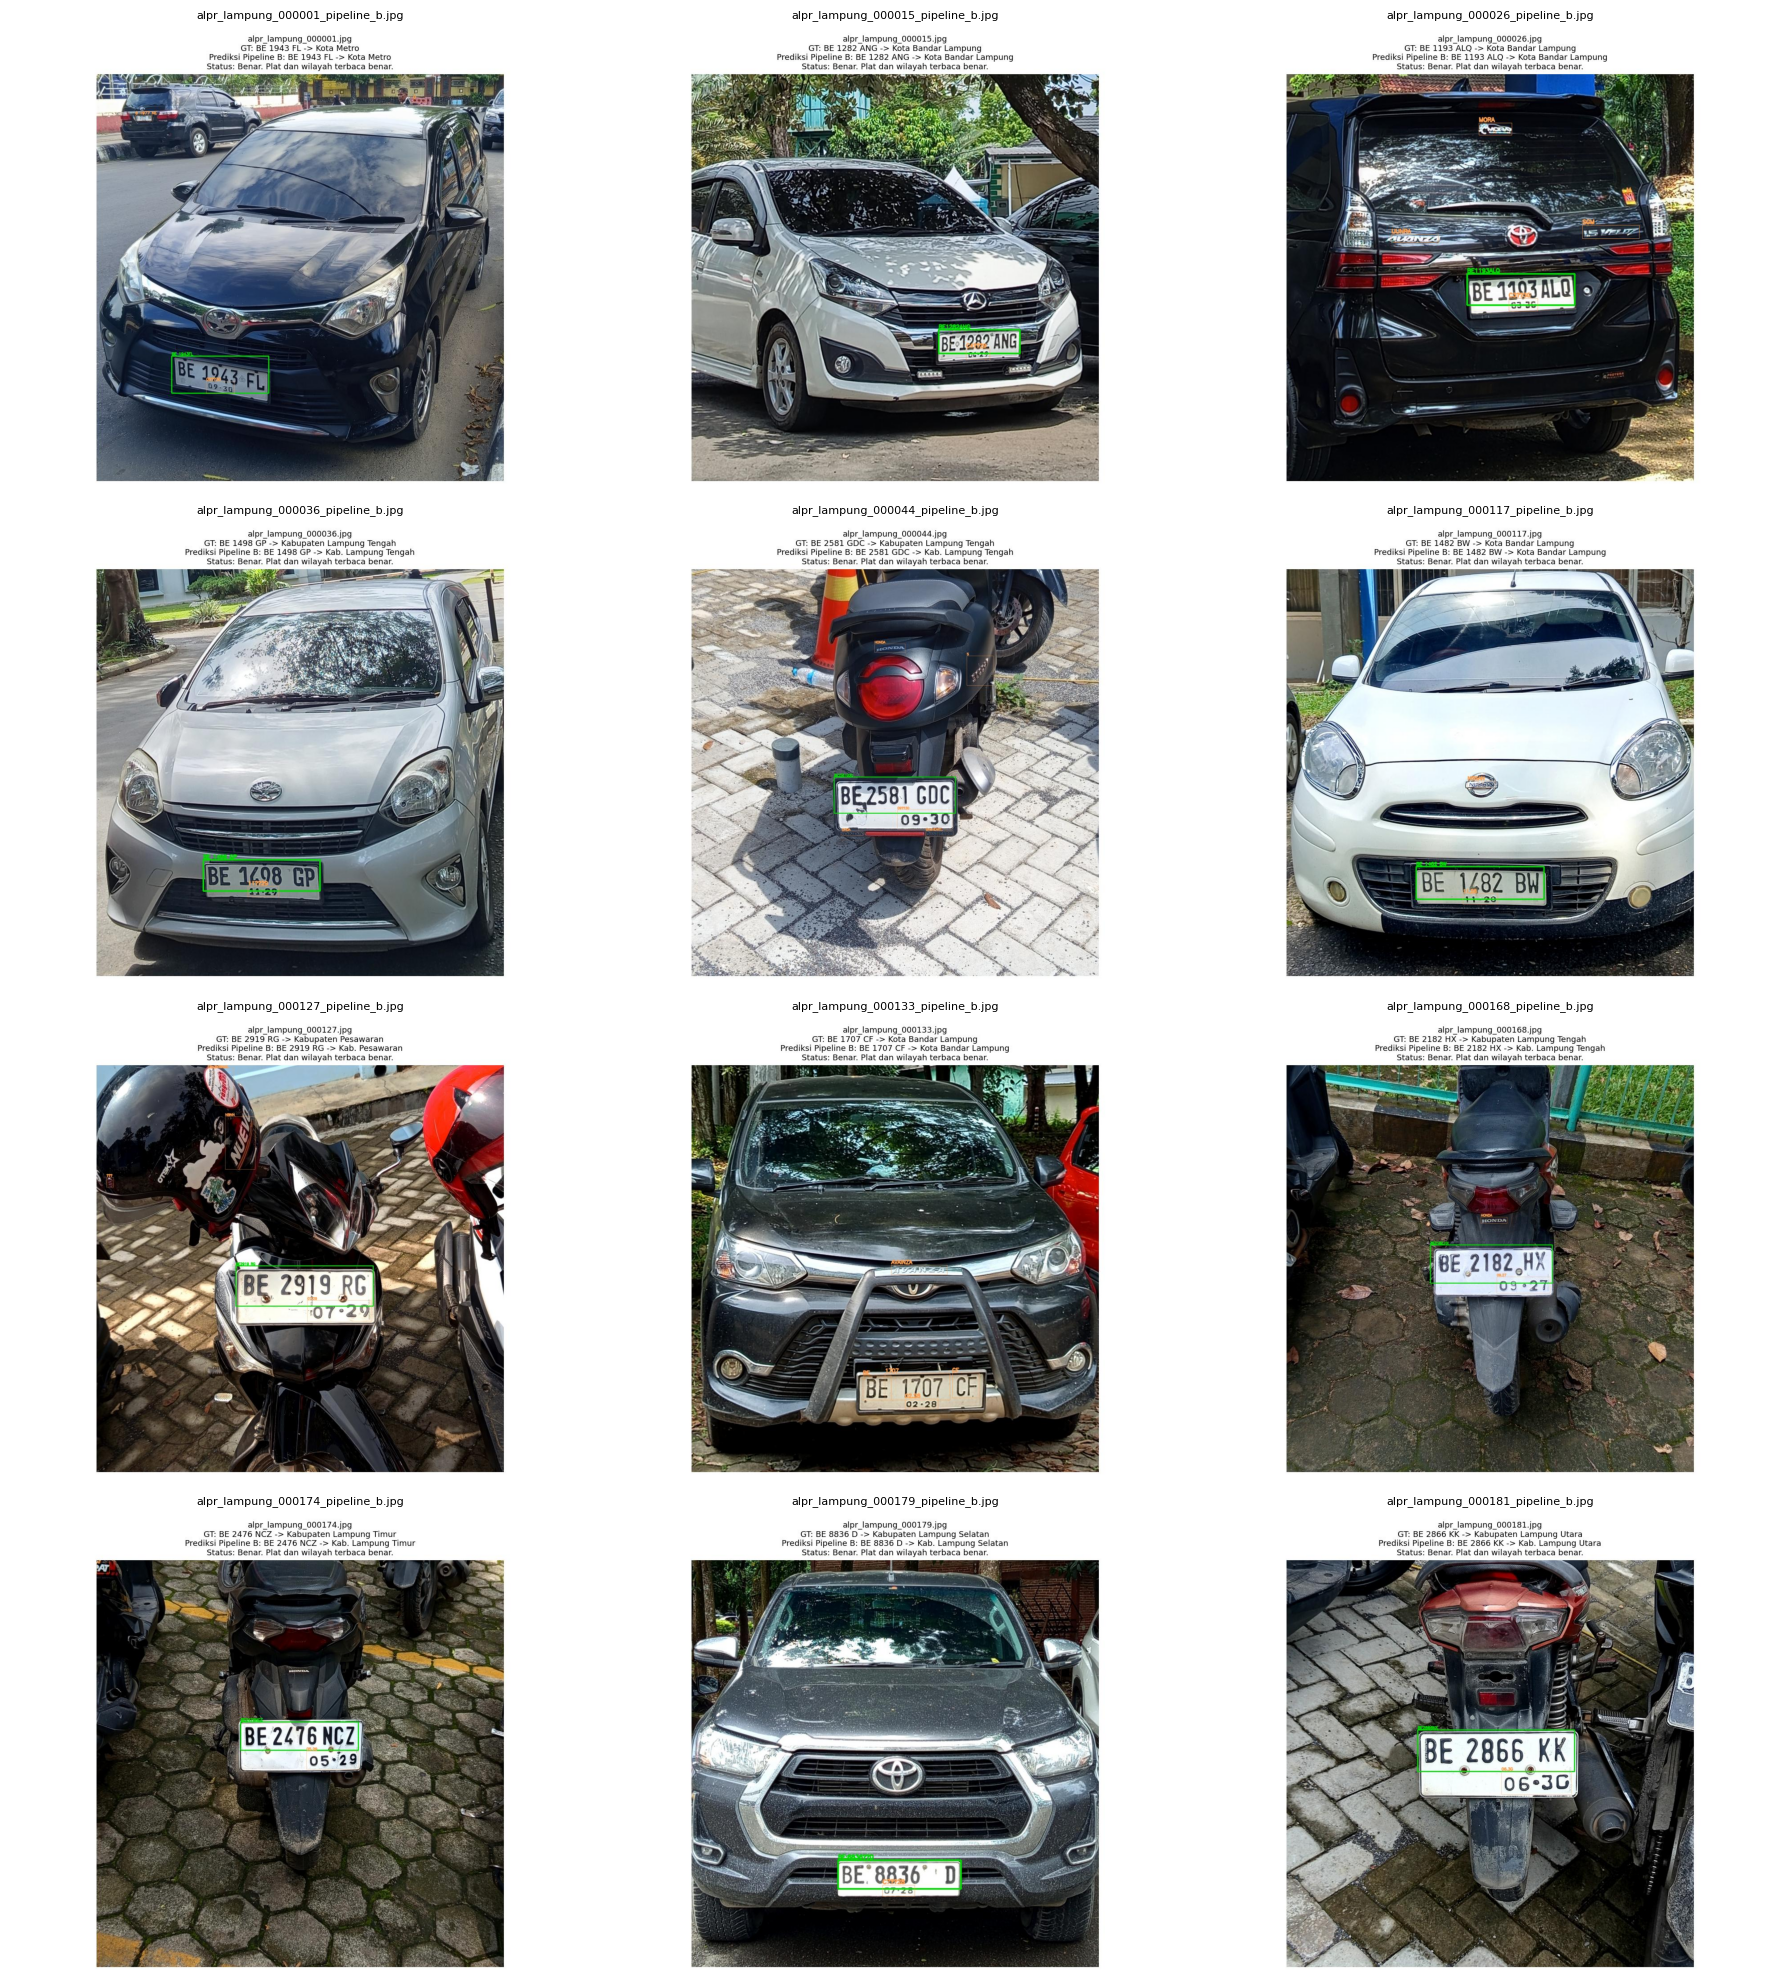

visualisasi_hasil: /content/drive/MyDrive/ALPR-Lampung-results/pipeline_b/visualisasi_hasil


In [19]:
vis_files = sorted(VIS_DIR.glob('*_pipeline_b.jpg'))
if not vis_files:
    print('Belum ada visualisasi Pipeline B.')
else:
    sample_count = min(12, len(vis_files))
    sample_files = random.sample(vis_files, sample_count) if len(vis_files) > sample_count else vis_files
    cols = 3
    rows = math.ceil(len(sample_files) / cols)
    fig, axes = plt.subplots(rows, cols, figsize=(6 * cols, 5 * rows))
    axes = np.array(axes).reshape(-1)
    for ax, path in zip(axes, sample_files):
        img = cv2.imread(str(path))
        ax.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
        ax.set_title(path.name, fontsize=8)
        ax.axis('off')
    for ax in axes[len(sample_files):]:
        ax.axis('off')
    plt.tight_layout()
    plt.show()
    print('visualisasi_hasil:', VIS_DIR)

## 23. Perbandingan Pipeline A vs Pipeline B

Jika hasil Pipeline A v2 tersedia di Google Drive, notebook akan membacanya otomatis dan membuat tabel perbandingan. Jika tidak tersedia, tabel tetap dibuat dengan catatan bahwa hasil Pipeline A perlu diisi manual.

In [20]:
PIPELINE_A_ROOT = Path('/content/drive/MyDrive/ALPR-Lampung-results/pipeline_a')


def load_pipeline_a_summary() -> Optional[Dict[str, Any]]:
    candidates = [
        PIPELINE_A_ROOT / 'technical_outputs' / 'evaluation_summary_improved_v2.json',
        PIPELINE_A_ROOT / 'evaluation_summary_improved_v2.json',
    ]
    for path in candidates:
        if path.exists():
            with path.open() as f:
                return json.load(f)
    csv_candidates = [
        PIPELINE_A_ROOT / 'ringkasan_evaluasi_pipeline_a.csv',
        PIPELINE_A_ROOT / 'technical_outputs' / 'evaluation_summary_improved_v2.csv',
    ]
    for path in csv_candidates:
        if path.exists():
            df = pd.read_csv(path)
            if len(df):
                return df.iloc[0].to_dict()
    return None


summary_a = load_pipeline_a_summary()
if summary_a is None:
    comparison_ab_df = pd.DataFrame([
        {'Metrik': 'Akurasi teks plat persis', 'Pipeline A YOLO + OCR': None, 'Pipeline B Full Image OCR': summary_b['plate_exact_match_accuracy'], 'Catatan': 'Lebih tinggi lebih baik. Hasil Pipeline A belum ditemukan otomatis.'},
        {'Metrik': 'Rata-rata CER', 'Pipeline A YOLO + OCR': None, 'Pipeline B Full Image OCR': summary_b['mean_CER'], 'Catatan': 'Lebih rendah lebih baik.'},
        {'Metrik': 'Akurasi karakter', 'Pipeline A YOLO + OCR': None, 'Pipeline B Full Image OCR': summary_b['mean_character_accuracy'], 'Catatan': 'Lebih tinggi lebih baik.'},
        {'Metrik': 'Akurasi wilayah', 'Pipeline A YOLO + OCR': None, 'Pipeline B Full Image OCR': summary_b['region_classification_accuracy'], 'Catatan': 'Lebih tinggi lebih baik.'},
        {'Metrik': 'Waktu proses/gambar', 'Pipeline A YOLO + OCR': None, 'Pipeline B Full Image OCR': summary_b['average_inference_time_ms'], 'Catatan': 'Lebih rendah lebih cepat.'},
        {'Metrik': 'Jumlah OCR error', 'Pipeline A YOLO + OCR': None, 'Pipeline B Full Image OCR': summary_b['ocr_error_count'], 'Catatan': 'Lebih rendah lebih baik.'},
        {'Metrik': 'Jumlah kandidat gagal', 'Pipeline A YOLO + OCR': None, 'Pipeline B Full Image OCR': summary_b['no_valid_candidate_count'], 'Catatan': 'Lebih rendah lebih baik.'},
    ])
else:
    comparison_ab_df = pd.DataFrame([
        {'Metrik': 'Akurasi teks plat persis', 'Pipeline A YOLO + OCR': summary_a.get('plate_exact_match_accuracy'), 'Pipeline B Full Image OCR': summary_b['plate_exact_match_accuracy'], 'Catatan': 'Lebih tinggi lebih baik.'},
        {'Metrik': 'Rata-rata CER', 'Pipeline A YOLO + OCR': summary_a.get('mean_CER'), 'Pipeline B Full Image OCR': summary_b['mean_CER'], 'Catatan': 'Lebih rendah lebih baik.'},
        {'Metrik': 'Akurasi karakter', 'Pipeline A YOLO + OCR': summary_a.get('mean_character_accuracy'), 'Pipeline B Full Image OCR': summary_b['mean_character_accuracy'], 'Catatan': 'Lebih tinggi lebih baik.'},
        {'Metrik': 'Akurasi wilayah', 'Pipeline A YOLO + OCR': summary_a.get('region_classification_accuracy'), 'Pipeline B Full Image OCR': summary_b['region_classification_accuracy'], 'Catatan': 'Lebih tinggi lebih baik.'},
        {'Metrik': 'Waktu proses/gambar', 'Pipeline A YOLO + OCR': summary_a.get('average_inference_time_ms'), 'Pipeline B Full Image OCR': summary_b['average_inference_time_ms'], 'Catatan': 'Lebih rendah lebih cepat.'},
        {'Metrik': 'Jumlah OCR error', 'Pipeline A YOLO + OCR': summary_a.get('ocr_error_count'), 'Pipeline B Full Image OCR': summary_b['ocr_error_count'], 'Catatan': 'Lebih rendah lebih baik.'},
        {'Metrik': 'Jumlah kandidat gagal', 'Pipeline A YOLO + OCR': summary_a.get('no_valid_candidate_count'), 'Pipeline B Full Image OCR': summary_b['no_valid_candidate_count'], 'Catatan': 'Lebih rendah lebih baik.'},
    ])

comparison_ab_path = OUTPUT_ROOT_PATH / 'perbandingan_pipeline_a_vs_b.csv'
comparison_ab_df.to_csv(comparison_ab_path, index=False)
print('perbandingan_pipeline_a_vs_b.csv:', comparison_ab_path)
display(comparison_ab_df)

perbandingan_pipeline_a_vs_b.csv: /content/drive/MyDrive/ALPR-Lampung-results/pipeline_b/perbandingan_pipeline_a_vs_b.csv


,Metrik,Pipeline A YOLO + OCR,Pipeline B Full Image OCR,Catatan
0,Akurasi teks plat persis,1.000000,1.000000,Lebih tinggi lebih baik.
1,Rata-rata CER,0.000000,0.000000,Lebih rendah lebih baik.
2,Akurasi karakter,1.000000,1.000000,Lebih tinggi lebih baik.
3,Akurasi wilayah,1.000000,1.000000,Lebih tinggi lebih baik.
4,Waktu proses/gambar,6973.666403,2815.636454,Lebih rendah lebih cepat.
5,Jumlah OCR error,0.000000,0.000000,Lebih rendah lebih baik.
6,Jumlah kandidat gagal,0.000000,0.000000,Lebih rendah lebih baik.


## 24. Interpretasi Perbandingan

Jika Pipeline A lebih akurat, hal itu menunjukkan bahwa deteksi YOLO membantu mempersempit area OCR ke plat sehingga noise dari full image berkurang. Jika Pipeline B lebih cepat, itu wajar karena tidak ada tahap deteksi YOLO, tetapi risiko noise lebih besar.

Pipeline B bukan harus mengalahkan Pipeline A. Pipeline B berfungsi sebagai baseline full-image OCR untuk membuktikan apakah tahap deteksi plat pada Pipeline A benar-benar bermanfaat.

In [21]:
print('Output ramah pembaca:')
print('hasil_pipeline_b.csv                  :', hasil_pipeline_b_path)
print('ringkasan_evaluasi_pipeline_b.csv     :', summary_csv_path)
print('analisis_kesalahan_pipeline_b.csv     :', friendly_error_path)
print('dashboard_ringkas_pipeline_b.csv      :', dashboard_path)
print('perbandingan_pipeline_a_vs_b.csv      :', comparison_ab_path)
print('visualisasi_hasil                     :', VIS_DIR)
print()
print('Output teknis:')
print('ocr_results_pipeline_b.csv            :', technical_results_path)
print('evaluation_summary_pipeline_b.json    :', summary_json_path)
print('candidate_debug_pipeline_b.csv        :', candidate_debug_path)
print('error_analysis_pipeline_b.csv         :', technical_error_path)

print('\nDashboard Ringkas Pipeline B')
display(dashboard_b_df)

exact = int(pipeline_b_df['plate_exact_match'].sum())
region = int(pipeline_b_df['region_correct'].sum())
ocr_ok = int(pipeline_b_df['ocr_status'].eq('ok').sum())
candidate_ok = int(pipeline_b_df['candidate_status'].eq('ok').sum())
total = len(pipeline_b_df)

print('\nRingkasan Hasil untuk Pembaca Umum')
print(f'- Dari {total} gambar uji, OCR full image berhasil menghasilkan teks pada {ocr_ok} gambar.')
print(f'- Kandidat plat valid ditemukan pada {candidate_ok} gambar.')
print(f'- Sebanyak {exact} dari {total} plat terbaca persis sama dengan ground truth.')
print(f'- Sebanyak {region} dari {total} wilayah berhasil dikenali dengan benar.')
print('- Jika hasil Pipeline B lebih rendah dari Pipeline A, penyebab paling mungkin adalah OCR membaca teks lain/noise pada gambar penuh.')
print('- Pipeline B layak dijadikan baseline pembanding untuk menunjukkan manfaat YOLO pada Pipeline A.')

Output ramah pembaca:
hasil_pipeline_b.csv                  : /content/drive/MyDrive/ALPR-Lampung-results/pipeline_b/hasil_pipeline_b.csv
ringkasan_evaluasi_pipeline_b.csv     : /content/drive/MyDrive/ALPR-Lampung-results/pipeline_b/ringkasan_evaluasi_pipeline_b.csv
analisis_kesalahan_pipeline_b.csv     : /content/drive/MyDrive/ALPR-Lampung-results/pipeline_b/analisis_kesalahan_pipeline_b.csv
dashboard_ringkas_pipeline_b.csv      : /content/drive/MyDrive/ALPR-Lampung-results/pipeline_b/dashboard_ringkas_pipeline_b.csv
perbandingan_pipeline_a_vs_b.csv      : /content/drive/MyDrive/ALPR-Lampung-results/pipeline_b/perbandingan_pipeline_a_vs_b.csv
visualisasi_hasil                     : /content/drive/MyDrive/ALPR-Lampung-results/pipeline_b/visualisasi_hasil

Output teknis:
ocr_results_pipeline_b.csv            : /content/drive/MyDrive/ALPR-Lampung-results/pipeline_b/technical_outputs/ocr_results_pipeline_b.csv
evaluation_summary_pipeline_b.json    : /content/drive/MyDrive/ALPR-Lampung-res

,Aspek,Hasil,Arti Sederhana
0,Total gambar diuji,12,Jumlah gambar pada test set.
1,OCR berhasil membaca,12/12,Gambar yang menghasilkan teks OCR.
2,Plat berhasil diparsing,12/12,Gambar yang memiliki kandidat plat valid.
3,Teks plat benar persis,12/12,Prediksi sama persis dengan ground truth.
4,Wilayah benar,12/12,Wilayah hasil prediksi sama dengan ground truth.
5,Rata-rata waktu proses,2.82 detik/gambar,Waktu rata-rata OCR full image per gambar.



Ringkasan Hasil untuk Pembaca Umum
- Dari 12 gambar uji, OCR full image berhasil menghasilkan teks pada 12 gambar.
- Kandidat plat valid ditemukan pada 12 gambar.
- Sebanyak 12 dari 12 plat terbaca persis sama dengan ground truth.
- Sebanyak 12 dari 12 wilayah berhasil dikenali dengan benar.
- Jika hasil Pipeline B lebih rendah dari Pipeline A, penyebab paling mungkin adalah OCR membaca teks lain/noise pada gambar penuh.
- Pipeline B layak dijadikan baseline pembanding untuk menunjukkan manfaat YOLO pada Pipeline A.
